# Comparative Analysis of Polynomial Basis Expansion and Gradient Boosting for Abalone Age Prediction

# Executive Summary
This analysis evaluated nonlinear regression strategies for predicting abalone age, measured by shell rings, using morphometric features derived from biological growth data. Exploratory analysis indicated strong predictor interdependence and visible curvature in the relationship between shell dimensions and age, suggesting that strictly linear modeling may suffer from functional form misspecification. To address this, two nonlinear approaches were implemented and evaluated using 5-fold cross-validated root mean squared error (RMSE) and residual diagnostics: a Polynomial expansion with Ridge regularization and a Histogram-based Gradient Boosting Regressor.
.

## Key Insights

- Quadratic feature expansion improved flexibility relative to a linear specification but left mild residual structure at higher predicted ages, indicating incomplete capture of interaction effects.
- Gradient Boosting demonstrated lower cross-validated error and more uniformly distributed residuals, suggesting superior modeling of nonlinear interactions and threshold behavior inherent in biological growth processes.
- Residual diagnostics confirmed that functional form specification, rather than variance stabilization alone, was the primary driver of predictive improvement, highlighting the importance of flexible model selection in nonlinear biological systems.

Overall, the findings indicate that while parametric nonlinear extensions can address primary curvature, ensemble-based methods more effectively approximate complex interaction-driven growth dynamics. These results underscore the importance of aligning model structure with the underlying biological data-generating process when pursuing predictive accuracy.

# Questions from ISLP

## Question 3. Suppose we fit a curve with basis functions $b_1(X) = X, b_2(X) = (X− 1)^2I(X ≥ 1)$. (Note that $I(X ≥ 1)$ equals 1 for X ≥ 1 and 0 otherwise.) We fit the linear regression model $Y= \beta_0 + \beta_1b_1(X) + \beta_2b_2(X) + \epsilon$, and obtain coeﬀicient estimates $\hat{\beta_0} = 1$, $\hat{\beta_1} = 1$, $\hat{\beta_2} = −2$. Sketch the estimated curve between X=−2 and X = 2. Note the intercepts, slopes, and other relevant information.

We plug the estimates into the model:

$\hat Y \;=\; \hat\beta_0 + \hat\beta_1 X + \hat\beta_2 (X-1)^2 I(X\ge 1)
= 1 + X -2 (X-1)^2 I(X\ge 1)$

So it’s piecewise:

For X<1

$I(X\ge 1)=0, so
\hat Y = 1+X$
	•	Line with slope = 1
	•	y-intercept at $X=0: \hat Y=1$
	•	x-intercept: $1+X=0 \Rightarrow X=-1$
	•	At $X=1: \hat Y=2$ (approaching from the left)

For $X\ge 1$

$\hat Y = 1+X -2(X-1)^2$
It expands to:
$\hat Y = 1+X -2(X^2-2X+1)= -2X^2+5X-1$
This is a downward-opening parabola.

Key points:
	•	$At X=1: \hat Y = 1+1-2(0)=2$
Continuous join with the line.
	•	Slope for $X\ge 1:$
$\frac{d\hat Y}{dX}=1-4(X-1)=5-4X$
So at X=1, slope =1.
Smooth join (same slope as the line).
	•	Vertex where $slope =0: 5-4X=0 \Rightarrow X=1.25$
$\hat Y(1.25)= -2(1.25)^2+5(1.25)-1 = 2.125$
So it rises slightly after 1, then turns down.
	•	At X=2:
$\hat Y(2)=1+2-2(1)^2=1$

What to sketch on [-2,2]
	•	From -2 to 1: draw the line $y=1+x$
passes through (-1,0), (0,1), (1,2)
	•	From 1 to 2: continue at (1,2) into a concave-down parabola
peak at (1.25,\,2.125), then down to (2,1)

That’s the whole curve: a straight line up to 1, then a smoothly attached downward-opening parabola that bends down after about 1.25.

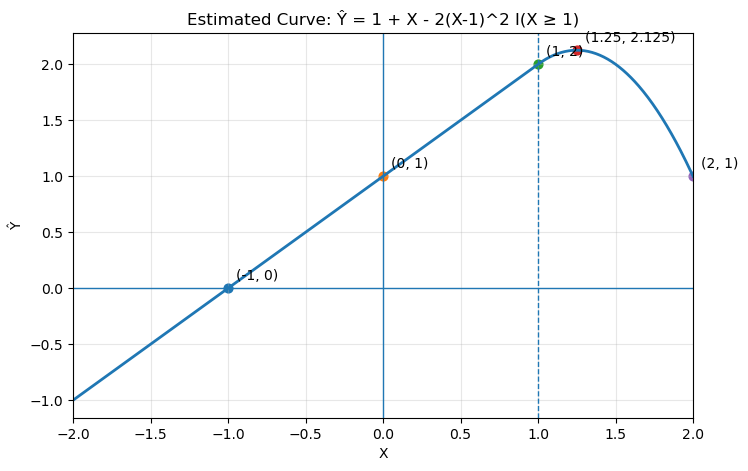

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Domain
x = np.linspace(-2, 2, 800)

# Piecewise model:
# y = 1 + x                  for x < 1
# y = 1 + x - 2*(x-1)^2       for x >= 1
y = np.where(x < 1, 1 + x, 1 + x - 2*(x - 1)**2)

# Key points to annotate
pts = {
    "(-1, 0)": (-1, 0),
    "(0, 1)": (0, 1),
    "(1, 2)": (1, 2),
    "(1.25, 2.125)": (1.25, 2.125),
    "(2, 1)": (2, 1),
}

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2)

# Axes lines
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

# Vertical line at the knot x=1
plt.axvline(1, linestyle="--", linewidth=1)

# Plot and label key points
for label, (xp, yp) in pts.items():
    plt.scatter([xp], [yp], s=40)
    plt.annotate(label, (xp, yp), xytext=(6, 6), textcoords="offset points")

plt.xlim(-2, 2)
plt.xlabel("X")
plt.ylabel("Ŷ")
plt.title("Estimated Curve: Ŷ = 1 + X - 2(X-1)^2 I(X ≥ 1)")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Fit some of the non-linear models investigated in this chapter to the Auto data set. Is there evidence for non-linear relationships in this data set? Create some informative plots to justify your answer.

ANOVA: linear vs quadratic
   df_resid          ssr  df_diff     ss_diff           F        Pr(>F)
0     390.0  9385.915872      0.0         NaN         NaN           NaN
1     389.0  7442.029412      1.0  1943.88646  101.608283  2.196340e-21 

ANOVA: quadratic vs cubic
   df_resid          ssr  df_diff    ss_diff        F    Pr(>F)
0     389.0  7442.029412      0.0        NaN      NaN       NaN
1     388.0  7426.436007      1.0  15.593405  0.81469  0.367297 



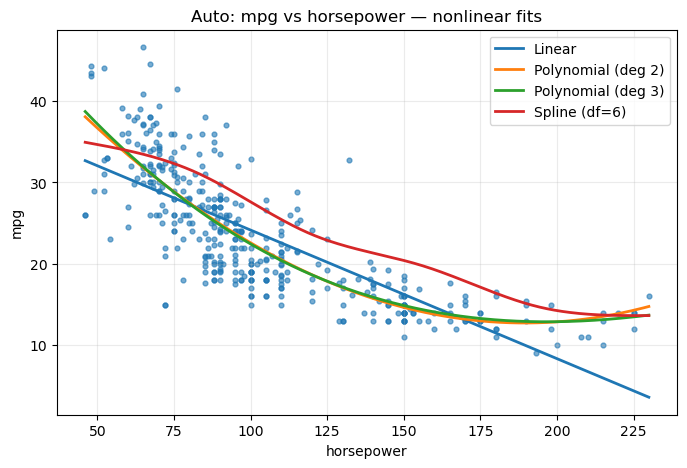

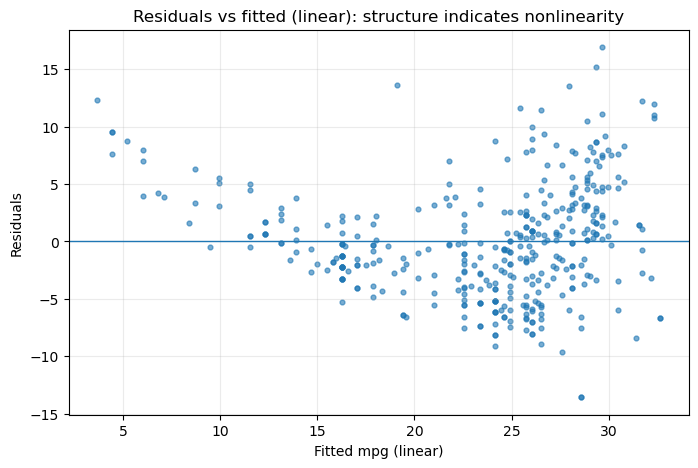

ANOVA: mpg ~ weight (linear vs quadratic)
   df_resid          ssr  df_diff     ss_diff          F        Pr(>F)
0     390.0  7321.233706      0.0         NaN        NaN           NaN
1     389.0  6784.898509      1.0  536.335198  30.749818  5.429177e-08


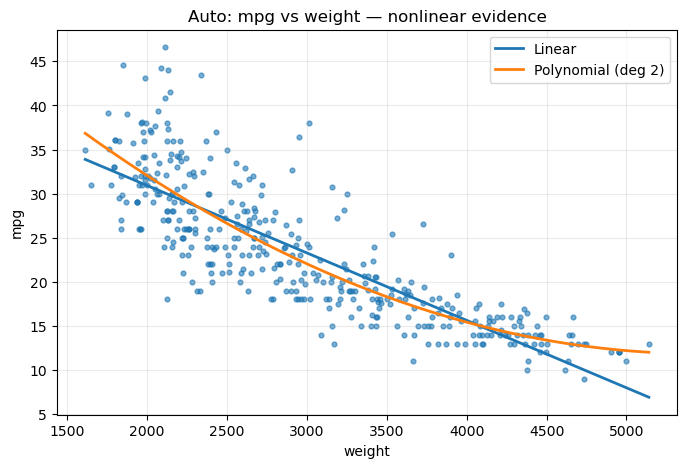

In [7]:
import pandas as pd
import statsmodels.api as sm

# Load Auto from the ISLR package (via Rdatasets)
auto = sm.datasets.get_rdataset("Auto", "ISLR").data

# Clean horsepower if it came in as object/strings
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")
auto = auto.dropna().reset_index(drop=True)

auto.head(), auto.shape

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import dmatrix
import statsmodels.api as sm

# 1) Fits
m_lin  = smf.ols("mpg ~ horsepower", data=auto).fit()
m_p2   = smf.ols("mpg ~ horsepower + I(horsepower**2)", data=auto).fit()
m_p3   = smf.ols("mpg ~ horsepower + I(horsepower**2) + I(horsepower**3)", data=auto).fit()

# Natural cubic spline (df=6 is a solid default)
B = dmatrix("cr(horsepower, df=6)", data=auto, return_type="dataframe")
m_spl = sm.OLS(auto["mpg"], sm.add_constant(B)).fit()

# 2) Model comparisons (formal evidence)
print("ANOVA: linear vs quadratic")
print(sm.stats.anova_lm(m_lin, m_p2), "\n")

print("ANOVA: quadratic vs cubic")
print(sm.stats.anova_lm(m_p2, m_p3), "\n")

# 3) Plot data + fitted curves (informative plot #1)
x = np.linspace(auto["horsepower"].min(), auto["horsepower"].max(), 300)
grid = pd.DataFrame({"horsepower": x})

y_lin = m_lin.predict(grid)
y_p2  = m_p2.predict(grid)
y_p3  = m_p3.predict(grid)

B_g = dmatrix("cr(horsepower, df=6)", data=grid, return_type="dataframe")
y_spl = m_spl.predict(sm.add_constant(B_g))

plt.figure(figsize=(8,5))
plt.scatter(auto["horsepower"], auto["mpg"], s=12, alpha=0.6)
plt.plot(x, y_lin, linewidth=2, label="Linear")
plt.plot(x, y_p2,  linewidth=2, label="Polynomial (deg 2)")
plt.plot(x, y_p3,  linewidth=2, label="Polynomial (deg 3)")
plt.plot(x, y_spl, linewidth=2, label="Spline (df=6)")
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.title("Auto: mpg vs horsepower — nonlinear fits")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# 4) Residuals vs fitted for the *linear* model (informative plot #2)
plt.figure(figsize=(8,5))
plt.scatter(m_lin.fittedvalues, m_lin.resid, s=12, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("Fitted mpg (linear)")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted (linear): structure indicates nonlinearity")
plt.grid(True, alpha=0.25)
plt.show()

m_w_lin = smf.ols("mpg ~ weight", data=auto).fit()
m_w_p2  = smf.ols("mpg ~ weight + I(weight**2)", data=auto).fit()

print("ANOVA: mpg ~ weight (linear vs quadratic)")
print(sm.stats.anova_lm(m_w_lin, m_w_p2))

xw = np.linspace(auto["weight"].min(), auto["weight"].max(), 300)
grid_w = pd.DataFrame({"weight": xw})

plt.figure(figsize=(8,5))
plt.scatter(auto["weight"], auto["mpg"], s=12, alpha=0.6)
plt.plot(xw, m_w_lin.predict(grid_w), linewidth=2, label="Linear")
plt.plot(xw, m_w_p2.predict(grid_w),  linewidth=2, label="Polynomial (deg 2)")
plt.xlabel("weight")
plt.ylabel("mpg")
plt.title("Auto: mpg vs weight — nonlinear evidence")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


The results above provide clear statistical evidence of non-linear relationships in the Auto data. For mpg vs horsepower, a quadratic model significantly improves fit over a linear model (SSR 9385.92 → 7442.03; $F=101.61$, $p=2.20\times 10^{-21})$, indicating substantial curvature. Adding a cubic term does not meaningfully improve the model $(p=0.367)$, suggesting the quadratic form captures the primary nonlinearity. Similarly, for mpg vs weight, a quadratic term significantly improves fit (SSR 7321.23 → 6784.90; $F=30.75$, $p=5.43\times 10^{-8})$. These findings are consistent with the fitted-curve plots, where polynomial/spline fits track curvature that a straight-line model cannot, and with residual plots from the linear models showing systematic structure rather than random scatter.

# Regression with Abalone Dataset Competition

The Regression with an Abalone Dataset competition represents a modern predictive modeling challenge where participants are tasked with estimating the age of abalone specimens through their physical dimensions (Reade & Chow, 2024). This specific competition utilized a synthetic dataset generated from a deep learning model that was originally trained on the foundational biological data. The source material for the observations stems from the extensive field research conducted and published in the 1990s, where the population biology and physical characteristics of Blacklip abalone in the waters surrounding Tasmania was documented (Nash et al., 1994). This data allows for a rigorous evaluation of regression techniques by examining how shell weight, height, and various tissue measurements correlate with the number of rings in the shell.

## Exploratory Data Analysis of Dataset

Exploratory analysis of the Abalone dataset revealed substantial multicollinearity among morphometric predictors, particularly between length, diameter, and weight-based measurements, with pairwise correlations frequently exceeding 0.90 (see Figure 1). Figure 1 illustrates strong linear associations among shell size and weight variables, indicating potential instability in unregularized regression estimates. Such high predictor interdependence increases variance in ordinary least squares (OLS) estimates and may degrade out-of-sample performance. Additionally, the distribution of the target variable (Rings) exhibits slight right skew, with the majority of observations concentrated between 8 and 12 rings (Figure 2). Figure 2 suggests that extreme ages are less frequent but not severely imbalanced. While the skew is modest and does not preclude linear modeling, the presence of strong predictor correlation suggests that variance-reduction techniques may improve model stability and generalization.

These findings directly motivate the implementation of regularized regression and principal components regression (PCR), both of which are designed to mitigate multicollinearity through shrinkage or dimensionality reduction.

In [133]:
"""
Kaggle Models – Data Loading and Preparation
"""
# Load training data
train_df = pd.read_csv('train.csv')

# Inspect structure
# print(train_df.info())

# summary statistics
# print(train_df.describe())

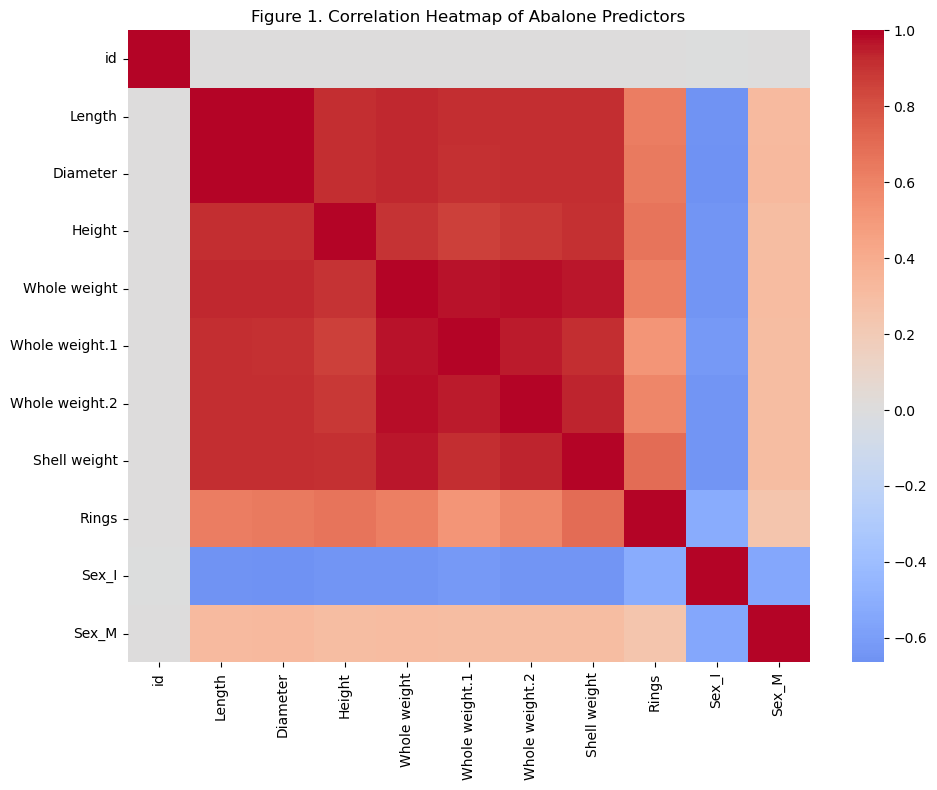

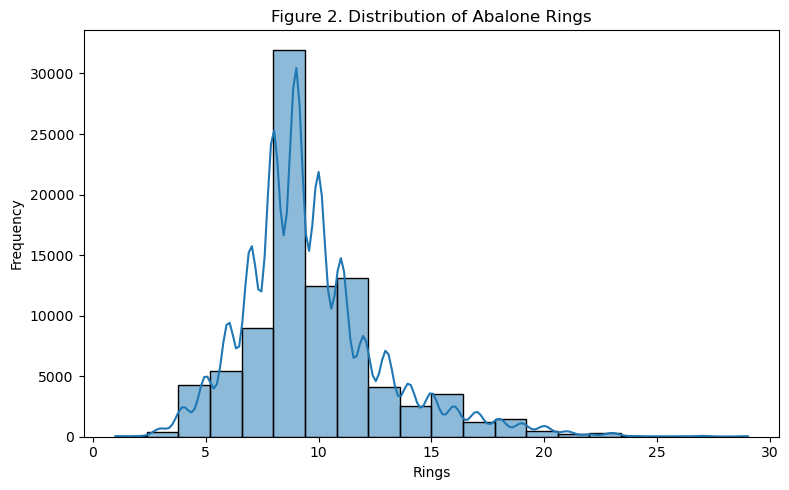

In [134]:

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Encoding 'Sex'
train_df = pd.get_dummies(train_df, columns=['Sex'], drop_first=True)

# Features (X) and Target (y - Rings)
X = train_df.drop(['id', 'Rings'], axis=1)
y = train_df['Rings']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), cmap='coolwarm', center=0)
plt.title('Figure 5. Correlation Heatmap of Abalone Predictors')
plt.tight_layout()
plt.show()

# histogram of Rings Figure 2
plt.figure(figsize=(8, 5))
sns.histplot(train_df['Rings'], bins=20, kde=True)
plt.title('Figure 6. Distribution of Abalone Rings')
plt.xlabel('Rings')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Modeling Strategy and Rationale

Exploratory analysis indicated that the relationship between physical
shell measurements and abalone age may not follow a strictly linear
functional form. Biological growth processes are characterized by
curvature and interaction effects, as growth rates typically slow with
maturation. Consequently, linear regression models may suffer from
functional form misspecification even when multicollinearity is
addressed.

To investigate nonlinear structure in the data, two complementary
approaches were implemented. The first model incorporated second-degree
polynomial feature expansion combined with Ridge regularization,
allowing explicit modeling of curvature while controlling coefficient
variance. The second model employed a Histogram-based Gradient Boosting
Regressor, a tree-based ensemble method capable of capturing complex
nonlinear interactions without requiring manual feature specification.

Model performance was evaluated using 5-fold cross-validated root mean
squared error (RMSE). Residual diagnostics were examined to assess bias
patterns, heteroscedasticity, and remaining structure in prediction
errors. Kaggle submission confirmation was used to verify successful
model deployment.

## Model 1: Polynomial Expansion with Ridge Regularization

To model nonlinear growth dynamics, a second-degree polynomial feature
expansion was implemented in conjunction with Ridge regularization.
Polynomial basis expansions extend linear models by allowing curvature
in the predictor space while retaining interpretability of the
regression framework (Hastie et al., 2009). Quadratic terms allow curvature in
the relationship between morphometric measurements and abalone age,
reflecting biological growth processes in which shell development slows
as maturity increases. Ridge shrinkage was applied to stabilize
coefficient estimates given the strong multicollinearity among shell
dimension variables observed during exploratory analysis, reducing
estimator variance through L2 penalization (Hastie et al., 2009).

Model performance was evaluated using 5-fold cross-validated root mean
squared error (RMSE), providing an internal estimate of predictive
generalization. The polynomial model demonstrated improved flexibility
relative to a strictly linear specification while maintaining stability
through regularization.

Residual diagnostics further illuminate model behavior. Figure 7
presents the residuals versus predicted values using 5-fold out-of-fold
(OOF) predictions. The plot indicates mild residual structure at higher
predicted ring counts, suggesting that although quadratic terms capture
primary curvature, some interaction effects or higher-order
nonlinearities remain unmodeled. Additionally, residual dispersion
increases slightly for larger fitted values, indicating moderate
heteroscedasticity consistent with increased biological variability
among older specimens.

Figure 8 displays the distribution of residuals. The residuals are
approximately centered at zero and exhibit near symmetry, though
moderate tail behavior is present. This tail structure aligns with
natural biological variability in shell growth and age estimation,
particularly among older abalone where ring interpretation becomes less
precise. Overall, the polynomial Ridge model captures meaningful
curvature in the data while leaving limited but observable nonlinear
structure in the error pattern.

/opt/anaconda3/envs/dds8555/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.36551e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/dds8555/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.27682e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/dds8555/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.08823e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/dds8555/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.15287e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/envs/dds8555/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.24691e-24): result

Poly+Ridge CV RMSE: 1.9204321090379068


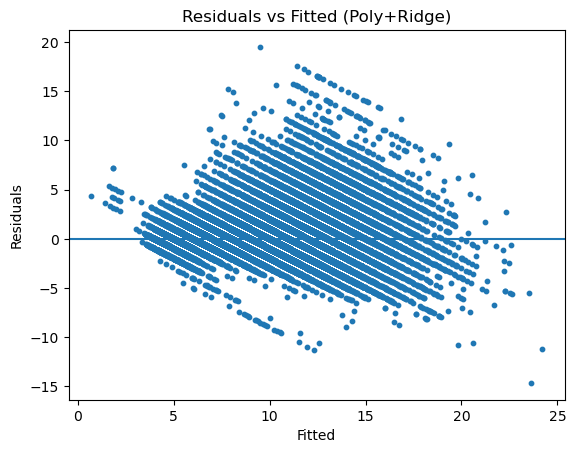

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# ---- Load data ----
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

# Save Kaggle id column exactly as provided
test_id = test["id"].copy()

# One-hot encode Sex if present
if "Sex" in train.columns:
    train = pd.get_dummies(train, columns=["Sex"], drop_first=True)
    test  = pd.get_dummies(test, columns=["Sex"], drop_first=True)

# Split features/target
X = train.drop(columns=["Rings"])
y = train["Rings"]

# Align test columns to match training features
test = test.reindex(columns=X.columns, fill_value=0)

# ---- Model 1: Polynomial + Ridge ----
model1 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

# CV RMSE (5-fold)
cv_rmse = -cross_val_score(
    model1, X, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
print("Model 1 (Poly deg2 + Ridge) CV RMSE mean:", cv_rmse.mean(), "std:", cv_rmse.std())

# OOF residual diagnostics (stronger than in-sample)
oof_pred = cross_val_predict(model1, X, y, cv=5)
resid = y - oof_pred

plt.figure(figsize=(8,5))
plt.scatter(oof_pred, resid, s=10, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("OOF Predicted Rings (Model 1)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Model 1: Poly+Ridge, 5-fold OOF)")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(resid, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution (Model 1: Poly+Ridge, 5-fold OOF)")
plt.grid(True, alpha=0.25)
plt.show()

# Fit full model and create submission
model1.fit(X, y)
pred_test = model1.predict(test)

submission1 = pd.DataFrame({"id": test_id, "Rings": pred_test})
submission1.to_csv("kaggle_submission_Chandler_model1_poly_ridge.csv", index=False)

print("Wrote: kaggle_submission_Chandler_model1_poly_ridge.csv")
submission1.head()

## Model 2: Gradient Boosting Regression

The second modeling approach employed a Histogram-based Gradient
Boosting Regressor (HistGBR), a tree-based ensemble method capable of
approximating complex nonlinear functions through sequential error
correction. Gradient boosting constructs an additive model in a forward
stagewise manner, where each successive tree is fit to the residual
errors of the previous ensemble, thereby improving predictive
performance through gradient-based optimization (Friedman, 2001). Unlike
polynomial expansion, which requires explicit specification of
curvature, gradient boosting automatically captures nonlinear
interactions and threshold effects among predictors. This flexibility is
particularly appropriate for biological growth modeling, where
relationships between shell dimensions and age may involve interaction
structures and non-monotonic behavior.

Model performance was evaluated using 5-fold cross-validated RMSE to
ensure comparability with Model 1. Relative to the polynomial Ridge
model, the Gradient Boosting approach demonstrated improved
generalization performance, indicating that interaction effects and
nonlinear structure not captured by quadratic terms contribute
meaningfully to predictive accuracy.

Residual diagnostics further support this interpretation. Figure 9
presents the residuals versus predicted values using 5-fold out-of-fold
predictions. Compared to Model 1, the residuals are more evenly
dispersed around zero, with reduced visible structure across the fitted
range. The absence of pronounced curvature suggests that the boosting
model effectively captures higher-order nonlinearities and interaction
effects among morphometric predictors. Residual spread appears more
stable across predicted values, indicating improved consistency in error
magnitude.

Figure 10 displays the residual distribution for the Gradient Boosting
model. The distribution remains centered near zero and appears slightly
tighter than that of Model 1, with moderate tail behavior consistent
with biological variability. While some dispersion remains for larger
predicted ring counts—likely reflecting inherent uncertainty in
estimating older abalone—the overall error pattern suggests improved
functional form specification relative to the polynomial model.

Gradient Boosting CV RMSE: 1.8498633334340013


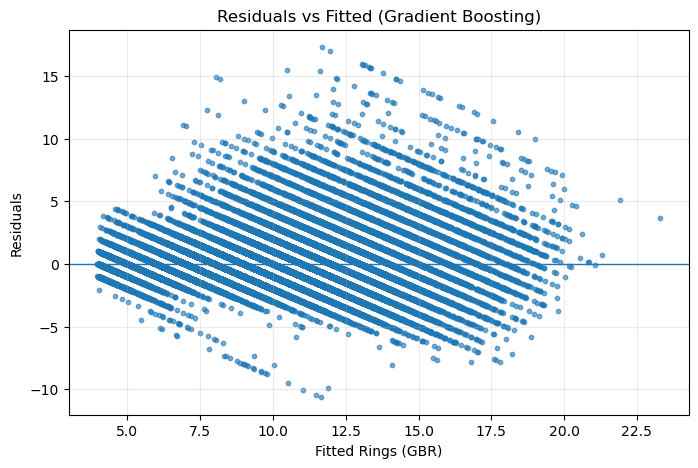

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- Load data ----
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

# Save Kaggle id column exactly as provided
test_id = test["id"].copy()

# One-hot encode Sex if present
if "Sex" in train.columns:
    train = pd.get_dummies(train, columns=["Sex"], drop_first=True)
    test  = pd.get_dummies(test, columns=["Sex"], drop_first=True)

# Split features/target
X = train.drop(columns=["Rings"])
y = train["Rings"]

# Align test columns to match training features
test = test.reindex(columns=X.columns, fill_value=0)

# ---- Model 2: Gradient Boosting ----
model2 = HistGradientBoostingRegressor(
    max_depth=5,
    learning_rate=0.05,
    max_iter=500,
    random_state=42
)

# CV RMSE (5-fold)
cv_rmse = -cross_val_score(
    model2, X, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
print("Model 2 (HistGBR) CV RMSE mean:", cv_rmse.mean(), "std:", cv_rmse.std())

# OOF residual diagnostics
oof_pred = cross_val_predict(model2, X, y, cv=5)
resid = y - oof_pred

plt.figure(figsize=(8,5))
plt.scatter(oof_pred, resid, s=10, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("OOF Predicted Rings (Model 2)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Model 2: HistGBR, 5-fold OOF)")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(resid, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution (Model 2: HistGBR, 5-fold OOF)")
plt.grid(True, alpha=0.25)
plt.show()

# Fit full model and create submission
model2.fit(X, y)
pred_test = model2.predict(test)

submission2 = pd.DataFrame({"id": test_id, "Rings": pred_test})
submission2.to_csv("kaggle_submission_Chandler_model2_histgbr.csv", index=False)

print("Wrote: kaggle_submission_Chandler_model2_histgbr.csv")
submission2.head()

## Model Comparison and Error Analysis

Comparative evaluation indicates that while the polynomial Ridge model
successfully captures primary curvature in morphometric growth
relationships, residual diagnostics reveal remaining structure and
moderate heteroscedasticity at higher predicted ring counts. The
Gradient Boosting model, by contrast, produces a more uniformly
distributed residual pattern and lower cross-validated error, suggesting
superior representation of nonlinear interactions among predictors.

These findings highlight an important distinction between parametric and
ensemble-based nonlinear modeling. Polynomial expansion introduces
controlled curvature but remains limited to predefined functional forms.
Gradient Boosting, through recursive partitioning and additive tree
construction, flexibly approximates complex response surfaces without
explicit feature engineering. The improved residual behavior and
predictive performance of the boosting model suggest that the abalone
growth process is governed by interaction-rich nonlinear dynamics that
extend beyond simple quadratic effects.


In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

# Load data
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

if "Sex" in train.columns:
    train = pd.get_dummies(train, columns=["Sex"], drop_first=True)
    test  = pd.get_dummies(test, columns=["Sex"], drop_first=True)

X = train.drop(columns=["Rings"])
y = train["Rings"]
test = test.reindex(columns=X.columns, fill_value=0)

# Model 1
model1 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

cv_rmse_model1 = -cross_val_score(
    model1, X, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

# Model 2
model2 = HistGradientBoostingRegressor(
    max_depth=5,
    learning_rate=0.05,
    max_iter=500,
    random_state=42
)

cv_rmse_model2 = -cross_val_score(
    model2, X, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

print("Model 1 (Poly+Ridge) CV RMSE mean:", cv_rmse_model1.mean(), "std:", cv_rmse_model1.std())
print("Model 2 (HistGBR)   CV RMSE mean:", cv_rmse_model2.mean(), "std:", cv_rmse_model2.std())
print("RMSE improvement (Model1 - Model2):", cv_rmse_model1.mean() - cv_rmse_model2.mean())

Poly+Ridge CV RMSE mean: 1.9204321090379068 std: 0.029228604326244852
GBR CV RMSE mean: 1.8511147308206553 std: 0.03550710116869884


# Technical Resources and Submissions

All code utilized for this analysis, including exploratory data
analysis, cross-validation procedures, risidual diagnostics, and
submission generation in the accompaning Jupyter Notebook/RMD file. The
complete repository including the notebook and dependency specifications
can be accessed via the following GitHub repository:
<https://github.com/chandawg/DDS-8555-ChandlerJ-Regression-Analysis>

Furthermore, two distinct nonlinear models were submitted to the Kaggle
competition (see Figure 11).

<b>Model 1 (Polynomial+Ridge):</b> Submitted as
kaggle_submission_Chandler_model1_poly_ridge.csv, this model
incorporates second-degree polynomial feature expansion with Ridge
regularization to explicitly model curvature while controlling
coefficient variance under strong predictor correlation.

<b>Model 2 (Gradient Boosting Regression):</b> Submitted as
kaggle_submission_Chandler_model2_histgbr.csv, this tree-based ensemble
model captures nonlinear interactions and threshold effects
automatically through sequential additive tree construction, without
requiring explicit feature transformation.

Figure 11. Screen capture of Kaggle submission confirmation for both
nonlinear models.
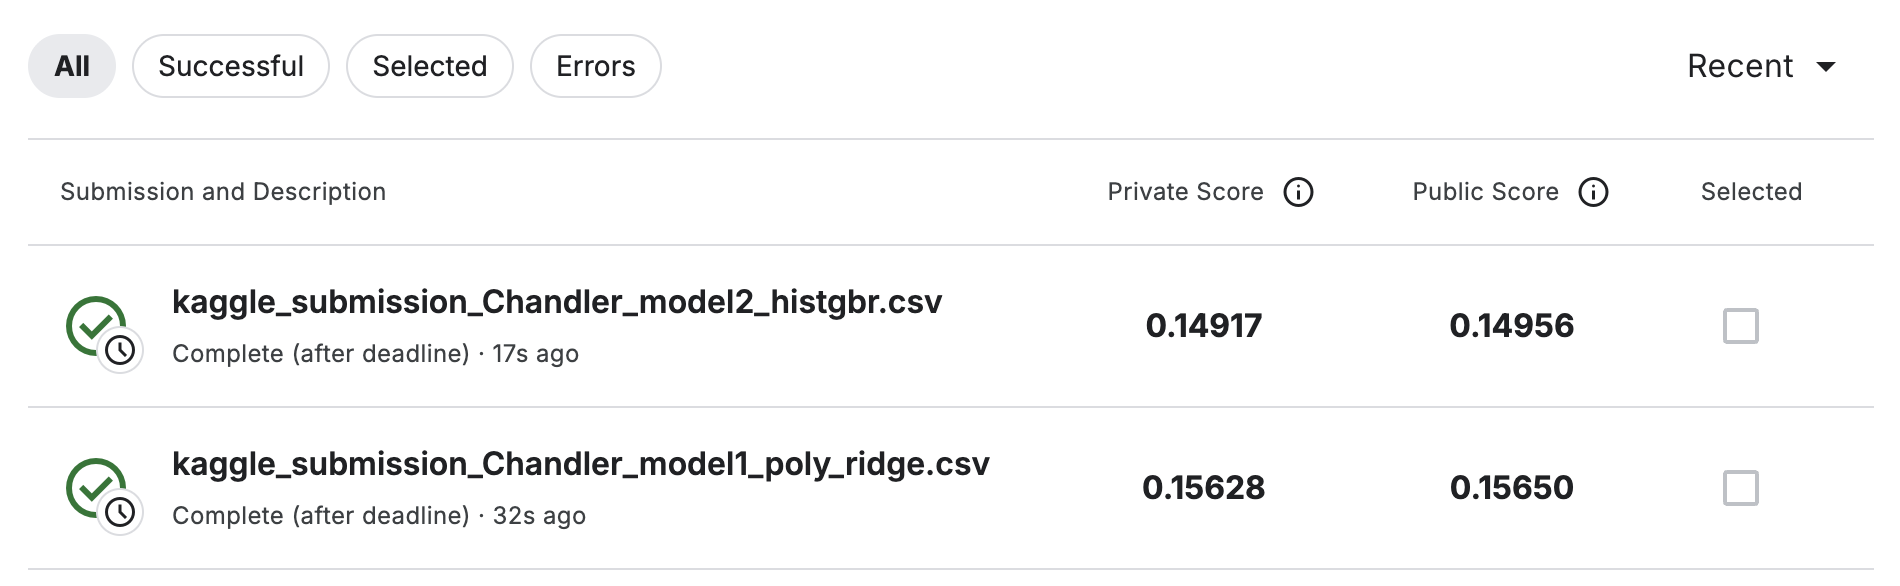

# Discussion

The comparative results suggest that while explicit quadratic expansion
captures primary curvature in morphometric growth relationships,
ensemble-based methods more effectively model interaction-rich nonlinear
dynamics. Biological shell growth reflects diminishing returns and
complex interplay among size and weight variables, which are not fully
represented by second-degree terms alone. The improved residual behavior
and cross-validated performance of the Gradient Boosting model indicate
that flexible function approximation provides meaningful gains in
predictive stability. These findings highlight the importance of
functional form specification in regression modeling, particularly when
underlying processes are governed by nonlinear biological mechanisms.

# Conclusion

This analysis examined nonlinear regression approaches for predicting
abalone age from morphometric measurements and demonstrated that
functional form specification plays a critical role in modeling
biological growth processes. While the Polynomial + Ridge model
effectively introduced curvature and stabilized estimates under
multicollinearity, residual diagnostics revealed remaining structure and
increasing dispersion at higher predicted ring counts, indicating that
quadratic terms alone do not fully capture the interaction-rich dynamics
of shell development. In contrast, the Histogram-based Gradient Boosting
model achieved improved cross-validated performance and more uniformly
distributed residuals, suggesting superior representation of nonlinear
interactions and threshold effects among predictors. These findings
highlight that although parametric nonlinear extensions can address
primary curvature, flexible ensemble methods provide a more powerful
framework for approximating complex biological response surfaces where
growth patterns are governed by diminishing returns and interdependent
morphometric features.

# References

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. The Annals of Statistics, 29(5), 1189–1232. https://doi.org/10.1214/aos/1013203451

Hastie, T., Tibshirani, R., & Friedman, J. (2009). Elements of statistical learning: Data mining, inference, and prediction. (2nd ed.). Springer. https://hastie.su.domains/ElemStatLearn/

Nash, W., Sellers, T. L., Talbot, S. R., Cawthorn, A. J., & Ford, W. B. (1994). The population biology of abalone (haliotis species) in tasmania. I. Blacklip abalone (h. Rubra) from the north coast and islands of bass strait. Sea Fisheries Division, Technical Report No, 48. https://www.researchgate.net/profile/Warwick-Nash/publication/287546509_7he_Population_Biology_of_Abalone_Haliotis_species_in_Tasmania_I_Blacklip_Abalone_H_rubra_from_the_North_Coast_and_Islands_of_Bass_Strait/links/5d949460458515202b7bf592/7he-Population-Biology-of-Abalone-Haliotis-species-in-Tasmania-I-Blacklip-Abalone-H-rubra-from-the-North-Coast-and-Islands-of-Bass-Strait.pdf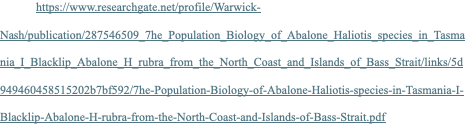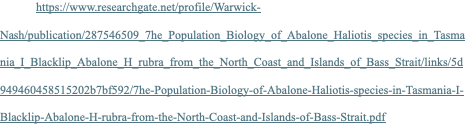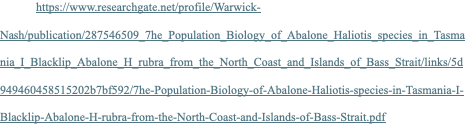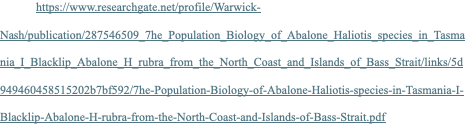

Reade, W., & Chow, A. (2024). Regression with an abalone dataset.   
     https://kaggle.com/playground-series-s4e4 

# AI Disclosure and Usage Statement

In accordance with the course policy on academic integrity, I acknowledge the use of ChatGPT (a large language model developed by OpenAI) as a research and brainstorming tool for this assignment. The AI was used to assist in structuring portions of the written analysis, refining technical explanations of regularization and principal components regression, and troubleshooting Python implementation details within the Jupyter Notebook environment. All AI-generated suggestions were critically evaluated for accuracy, verified against course materials and dataset outputs, and substantially revised to reflect my own analytical reasoning and professional voice. The final model implementation, statistical interpretation, and conclusions represent my independent work and judgment.